# Partielle Differentialgleichungen

## Aufgabenstellung
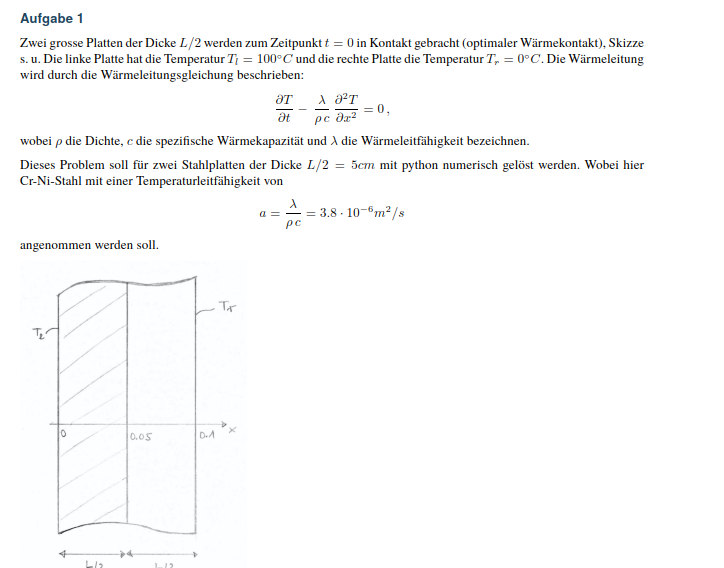



## Randbediungensarten


Fixe werte am Rand sind vorgegeben, bsp 0 und 200 Grad <br>
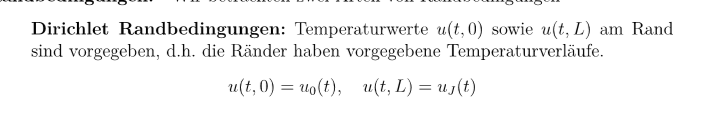 <br>
Steigungen am Rand sind vorgegeben, also pro zeit <br>
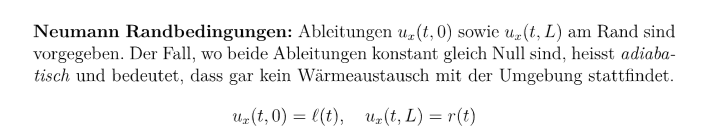 <br>
beispiel, man weiss aber nicht welches welches ist nur von bild!! <br>
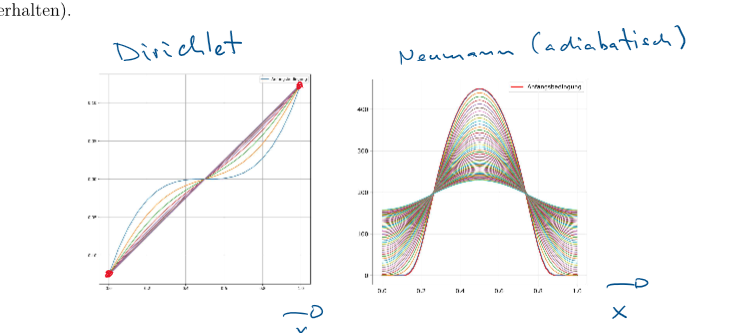 <br>

### Aufgabe 1.1
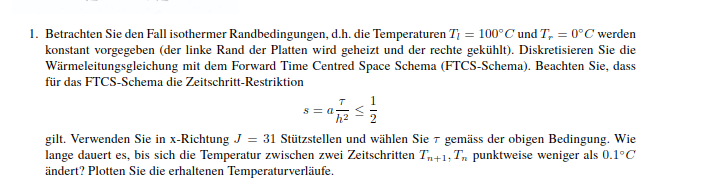

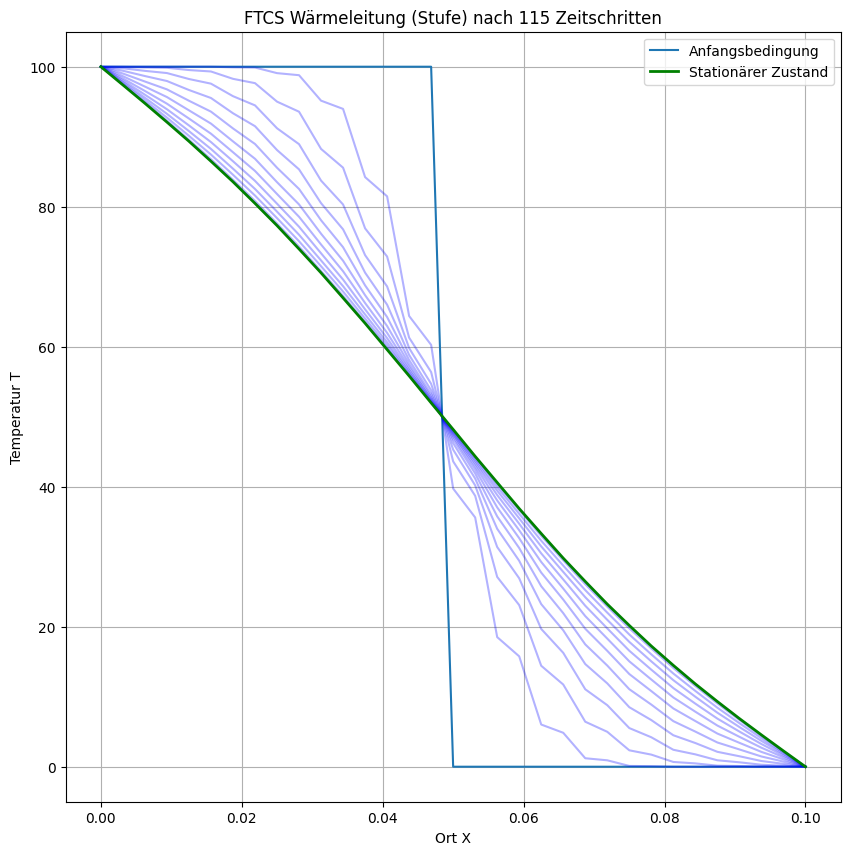

1.4327485380116964
0.49


In [ ]:
import numpy as np
from matplotlib import pyplot as plt

### AUS Biepiel pDGL, FCTS

#%% Parameter
a = 3.8 * 10**-6           # Temperaturleitfähigkeit aus aufgabenstellung 

L = 0.1           # Länge des x-Intervalls
J = 31          # Anzahl Unterteilungen in x-Richtung

tol = 0.1
schritte = 0

# Diskretisierung
h   = L / (J-1)           # räumliche Diskretisierung ("Ortsschritt")


s = 0.49
tau = s * h**2 / a # Zeitschritt (Stabilitätsgrenze ist h**2 / a / 2)


t= 0 # zeit gebraucht
change = 100 ## genug hoch 

###Kopiert aus beispiel pDgl

X = np.linspace(0, L, J + 2)
T = np.zeros((2, J + 2))

T[0, 0]  = 100.0    # Randbedingung links
T[0, -1] = 0.0     # Randbedingung rechts


# --- NEUE ANFANGSBEDINGUNG ---
# Bestimmen, wo die Mitte des Arrays ist
mitte = len(X) // 2

# Erste Hälfte auf 100 setzen
T[0, :mitte] = 100.0

# Zweite Hälfte auf 0 setzen
T[0, mitte:] = 0.0
# ------------------------------


#%% FTCS
plt.figure(1,[10,10])
plt.plot(X, T[0], label = "Anfangsbedingung")
plt.grid(True)

## beispiel mit FOR for n in range(N):
## wir kennen aber t end nicht, daher mit while
## Berechnung mit der while-Schleife
while change > tol:
    
    # 1. FTCS-Berechnung komplett in T für alle inneren Punkte (T[1] neu berechnen aus T[0] alt)
    T[1, 1:-1] = s * (T[0, 2:] + T[0, :-2]) + (1 - 2 * s) * T[0, 1:-1]
    
    # 2. Randbedingungen für den soeben neu berechneten Schritt fixieren
    T[1, 0]  = 100.0
    T[1, -1] = 0.0    
    
    # 3. Maximale Temperaturänderung zwischen diesem und dem vorherigen Schritt messen
    change = np.max(np.abs(T[1] - T[0]))
    
    # 4. In regelmäßigen Zeitschritten den aktuellen Zustand plotten
    schritte += 1
    if schritte % 10 == 0:
        plt.plot(X, T[1], color="blue", alpha=0.3) # T[1] ist der neu berechnete Zustand
        
    # 5. ERST JETZT das alte T[0] mit den Werten des neu berechneten Schritts (T[1]) überschreiben
    T[0, :] = T[1, :]

# Finalen Zustand zur Verdeutlichung grün einzeichnen
plt.plot(X, T[1], color="green", label="Stationärer Zustand", linewidth=2)
plt.title(f"FTCS Wärmeleitung (Stufe) nach {schritte} Zeitschritten")
plt.xlabel("Ort X")
plt.ylabel("Temperatur T")
plt.legend()
plt.show()
print(tau)
print(s)


## Aufgabe 1.2